In [6]:
#Define Correct Dataset Path
import os

os.listdir('/kaggle/input/datasets/vipoooool/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)')

['valid', 'train']

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import time

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import confusion_matrix, classification_report

2026-03-07 15:51:01.808042: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772898662.002525      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772898662.054358      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772898662.502542      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772898662.502642      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772898662.502645      55 computation_placer.cc:177] computation placer alr

In [8]:
#define train and validation folders.
train_dir = "/kaggle/input/datasets/vipoooool/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train"
val_dir = "/kaggle/input/datasets/vipoooool/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid"

In [9]:
#Load Dataset
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = 255
BATCH_SIZE = 64

In [10]:
# Training generator
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical"
)

Found 70295 images belonging to 38 classes.


In [11]:
# Validation generator
val_datagen = ImageDataGenerator(rescale=1./255)

val_data = val_datagen.flow_from_directory(
    val_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical"
)

Found 17572 images belonging to 38 classes.


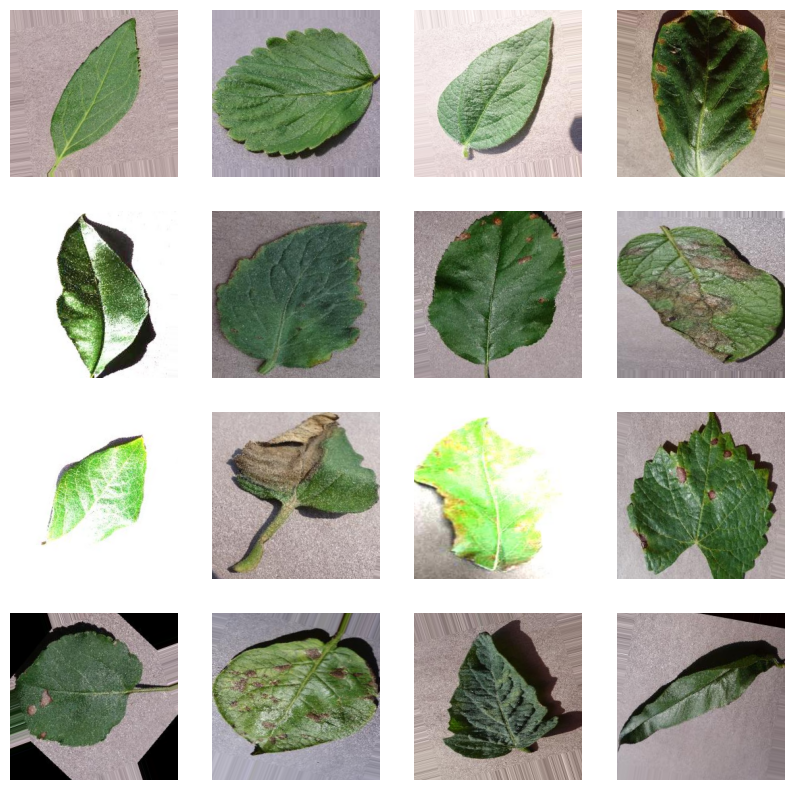

In [12]:
#Visualize Sample Images
images, labels = next(train_data)

plt.figure(figsize=(10,10))

for i in range(16):
    plt.subplot(4,4,i+1)
    plt.imshow(images[i])
    plt.axis("off")

plt.show()

In [13]:
IMG_SIZE = 255

In [14]:
# Model 1 : Shallow Neural Network 

In [15]:
model1 = models.Sequential([
    
    layers.Flatten(input_shape=(IMG_SIZE,IMG_SIZE,3)),
    
    layers.Dense(512,activation='relu'),
    
    layers.Dropout(0.5),
    
    layers.Dense(train_data.num_classes,activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
I0000 00:00:1772898708.210526      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


In [16]:
#Compile
model1.compile(
optimizer='adam',
loss='categorical_crossentropy',
metrics=['accuracy'])

In [17]:
history1 = model1.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10


I0000 00:00:1772898713.857725     151 service.cc:152] XLA service 0x780aec004810 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1772898713.857767     151 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1772898714.083295     151 cuda_dnn.cc:529] Loaded cuDNN version 91002


   1/1099 ━━━━━━━━━━━━━━━━━━━━ 1:16:13 4s/step - accuracy: 0.0469 - loss: 3.9517

I0000 00:00:1772898715.684694     151 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1099/1099 ━━━━━━━━━━━━━━━━━━━━ 1463s 1s/step - accuracy: 0.0306 - loss: 12.3484 - val_accuracy: 0.0551 - val_loss: 3.5525
Epoch 2/10
1099/1099 ━━━━━━━━━━━━━━━━━━━━ 1082s 984ms/step - accuracy: 0.0384 - loss: 3.6059 - val_accuracy: 0.0296 - val_loss: 3.6333
Epoch 3/10
1099/1099 ━━━━━━━━━━━━━━━━━━━━ 1043s 949ms/step - accuracy: 0.0330 - loss: 3.6261 - val_accuracy: 0.0495 - val_loss: 3.5611
Epoch 4/10
1099/1099 ━━━━━━━━━━━━━━━━━━━━ 1072s 975ms/step - accuracy: 0.0368 - loss: 3.6080 - val_accuracy: 0.0537 - val_loss: 3.5442
Epoch 5/10
1099/1099 ━━━━━━━━━━━━━━━━━━━━ 1055s 960ms/step - accuracy: 0.0376 - loss: 3.6025 - val_accuracy: 0.0531 - val_loss: 3.5432
Epoch 6/10
1099/1099 ━━━━━━━━━━━━━━━━━━━━ 1047s 952ms/step - accuracy: 0.0403 - loss: 3.5997 - val_accuracy: 0.0563 - val_loss: 3.5264
Epoch 7/10
1099/1099 ━━━━━━━━━━━━━━━━━━━━ 1082s 985ms/step - accuracy: 0.0403 - loss: 3.5949 - val_accuracy: 0.0553 - val_loss: 3.5274
Epoch 8/10
1099/1099 ━━━━━━━━━━━━━━━━━━━━ 1049s 955ms/step - accurac

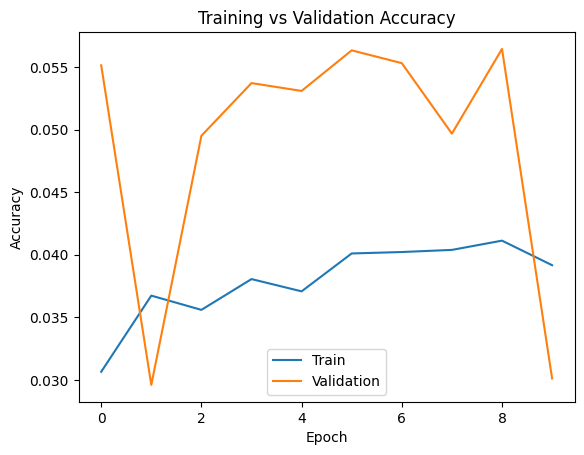

In [18]:
import matplotlib.pyplot as plt

plt.plot(history1.history['accuracy'])
plt.plot(history1.history['val_accuracy'])

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train","Validation"])

plt.show()

In [19]:
loss, accuracy = model1.evaluate(val_data)

print("Validation Accuracy:", accuracy)

275/275 ━━━━━━━━━━━━━━━━━━━━ 45s 163ms/step - accuracy: 0.0288 - loss: 3.6359
Validation Accuracy: 0.030104711651802063


In [20]:
# Model 2 — Deep Feedforward Neural Network

In [21]:
model2 = models.Sequential([

layers.Flatten(input_shape=(IMG_SIZE,IMG_SIZE,3)),

layers.Dense(1024,activation='relu'),
layers.BatchNormalization(),
layers.Dropout(0.4),

layers.Dense(512,activation='relu'),

layers.Dense(256,activation='relu'),

layers.Dense(train_data.num_classes,activation='softmax')

])

In [22]:
model2.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [23]:
history2 = model2.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10
1099/1099 ━━━━━━━━━━━━━━━━━━━━ 1038s 941ms/step - accuracy: 0.3205 - loss: 2.3966 - val_accuracy: 0.2514 - val_loss: 2.8679
Epoch 2/10
1099/1099 ━━━━━━━━━━━━━━━━━━━━ 1058s 963ms/step - accuracy: 0.5303 - loss: 1.5190 - val_accuracy: 0.4683 - val_loss: 1.6941
Epoch 3/10
1099/1099 ━━━━━━━━━━━━━━━━━━━━ 1050s 955ms/step - accuracy: 0.5707 - loss: 1.3595 - val_accuracy: 0.4460 - val_loss: 1.7375
Epoch 4/10
1099/1099 ━━━━━━━━━━━━━━━━━━━━ 1055s 960ms/step - accuracy: 0.5844 - loss: 1.3157 - val_accuracy: 0.4350 - val_loss: 1.9760
Epoch 5/10
1099/1099 ━━━━━━━━━━━━━━━━━━━━ 1065s 969ms/step - accuracy: 0.5907 - loss: 1.2862 - val_accuracy: 0.6294 - val_loss: 1.1553
Epoch 6/10
1099/1099 ━━━━━━━━━━━━━━━━━━━━ 1048s 954ms/step - accuracy: 0.5926 - loss: 1.2744 - val_accuracy: 0.5320 - val_loss: 1.5525
Epoch 7/10
1099/1099 ━━━━━━━━━━━━━━━━━━━━ 1031s 938ms/step - accuracy: 0.6013 - loss: 1.2554 - val_accuracy: 0.6937 - val_loss: 1.0094
Epoch 8/10
1099/1099 ━━━━━━━━━━━━━━━━━━━━ 1035s 942ms/s

In [24]:
# Model 3 — Shallow CNN

In [25]:
model3 = models.Sequential([

layers.Conv2D(32,(3,3),activation='relu',
              input_shape=(IMG_SIZE,IMG_SIZE,3)),

layers.MaxPooling2D(2,2),

layers.Conv2D(64,(3,3),activation='relu'),

layers.MaxPooling2D(2,2),

layers.Flatten(),

layers.Dense(128,activation='relu'),

layers.Dropout(0.5),

layers.Dense(train_data.num_classes,activation='softmax')

])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [26]:
model3.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [27]:
history3 = model3.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10
1099/1099 ━━━━━━━━━━━━━━━━━━━━ 1063s 960ms/step - accuracy: 0.2818 - loss: 2.8725 - val_accuracy: 0.6996 - val_loss: 0.9853
Epoch 2/10
1099/1099 ━━━━━━━━━━━━━━━━━━━━ 1029s 936ms/step - accuracy: 0.6363 - loss: 1.1963 - val_accuracy: 0.7344 - val_loss: 0.8752
Epoch 3/10
1099/1099 ━━━━━━━━━━━━━━━━━━━━ 1028s 935ms/step - accuracy: 0.7118 - loss: 0.9348 - val_accuracy: 0.8019 - val_loss: 0.6218
Epoch 4/10
1099/1099 ━━━━━━━━━━━━━━━━━━━━ 1072s 975ms/step - accuracy: 0.7363 - loss: 0.8462 - val_accuracy: 0.8347 - val_loss: 0.5408
Epoch 5/10
1099/1099 ━━━━━━━━━━━━━━━━━━━━ 1103s 1s/step - accuracy: 0.7669 - loss: 0.7402 - val_accuracy: 0.7699 - val_loss: 0.7962
Epoch 6/10
1099/1099 ━━━━━━━━━━━━━━━━━━━━ 1095s 997ms/step - accuracy: 0.7808 - loss: 0.6980 - val_accuracy: 0.8509 - val_loss: 0.4740
Epoch 7/10
1099/1099 ━━━━━━━━━━━━━━━━━━━━ 1020s 928ms/step - accuracy: 0.7987 - loss: 0.6395 - val_accuracy: 0.8106 - val_loss: 0.6388
Epoch 8/10
1099/1099 ━━━━━━━━━━━━━━━━━━━━ 1064s 968ms/step

In [28]:
# Model 4 — Deep CNN

In [29]:
model4 = models.Sequential([

layers.Conv2D(32,(3,3),padding='same',activation='relu',
              input_shape=(IMG_SIZE,IMG_SIZE,3)),

layers.MaxPooling2D(2,2),

layers.Conv2D(64,(3,3),padding='same',activation='relu'),

layers.MaxPooling2D(2,2),

layers.Conv2D(128,(3,3),padding='same',activation='relu'),

layers.MaxPooling2D(2,2),

layers.Conv2D(256,(3,3),padding='same',activation='relu'),

layers.GlobalAveragePooling2D(),

layers.Dense(256,activation='relu'),

layers.Dropout(0.5),

layers.Dense(38,activation='softmax')

])

In [30]:
model4.compile(
optimizer='adam',
loss='categorical_crossentropy',
metrics=['accuracy'])

In [31]:
early_stop = EarlyStopping(patience=3,restore_best_weights=True)

history4 = model4.fit(
train_data,
validation_data=val_data,
epochs=10,
callbacks=[early_stop])

Epoch 1/10
1099/1099 ━━━━━━━━━━━━━━━━━━━━ 1107s 998ms/step - accuracy: 0.1174 - loss: 3.1900 - val_accuracy: 0.4203 - val_loss: 2.0166
Epoch 2/10
1099/1099 ━━━━━━━━━━━━━━━━━━━━ 1044s 950ms/step - accuracy: 0.4814 - loss: 1.7112 - val_accuracy: 0.6418 - val_loss: 1.1385
Epoch 3/10
1099/1099 ━━━━━━━━━━━━━━━━━━━━ 1017s 925ms/step - accuracy: 0.6548 - loss: 1.1176 - val_accuracy: 0.7986 - val_loss: 0.6251
Epoch 4/10
1099/1099 ━━━━━━━━━━━━━━━━━━━━ 1025s 933ms/step - accuracy: 0.7546 - loss: 0.7789 - val_accuracy: 0.8535 - val_loss: 0.4505
Epoch 5/10
1099/1099 ━━━━━━━━━━━━━━━━━━━━ 1022s 930ms/step - accuracy: 0.8067 - loss: 0.6051 - val_accuracy: 0.8430 - val_loss: 0.4847
Epoch 6/10
1099/1099 ━━━━━━━━━━━━━━━━━━━━ 1052s 957ms/step - accuracy: 0.8394 - loss: 0.5010 - val_accuracy: 0.8582 - val_loss: 0.4323
Epoch 7/10
1099/1099 ━━━━━━━━━━━━━━━━━━━━ 1031s 938ms/step - accuracy: 0.8630 - loss: 0.4263 - val_accuracy: 0.9066 - val_loss: 0.2850
Epoch 8/10
1099/1099 ━━━━━━━━━━━━━━━━━━━━ 1062s 966ms/s

In [32]:
# Compare Model Performance

In [33]:
results = {
    "Shallow NN": max(history1.history['val_accuracy']),
"Deep NN": max(history2.history['val_accuracy']),
"Shallow CNN": max(history3.history['val_accuracy']),
"Deep CNN": max(history4.history['val_accuracy'])}

print(results)

{'Shallow NN': 0.05645344778895378, 'Deep NN': 0.6942294836044312, 'Shallow CNN': 0.881174623966217, 'Deep CNN': 0.9419531226158142}
